# HiP-AD Gradient Conflict Analysis (Interactive)

`analyze_gradient_conflict.py`를 단계별로 실행하며 중간 결과를 확인할 수 있는 노트북.

**분석 수준:**
- `basic` — 전체 pairwise cosine similarity만
- `full` — per-layer + interference + decomposition + active-overlap + SVD subspace
- `direction` — full + PCA gradient direction 시각화

**실행 순서:** 위에서 아래로 순서대로 실행. Config 셀에서 설정을 변경한 뒤 나머지를 실행.

## 0. GPU 설정 (torch import 전에 실행)

In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'  # 사용할 GPU 번호

## 1. Configuration

argparse 대신 여기서 직접 설정합니다. 필요에 따라 수정하세요.

In [27]:
from types import SimpleNamespace

args = SimpleNamespace(
    # === 필수 설정 ===
    config='projects/configs/hipad_b2d_stage2.py',
    checkpoint='/home/yongjae/e2e/HiP-AD/ckpts/code_epoch1.pth',  # 단일 체크포인트 경로

    # === 분석 설정 ===
    analysis_mode='full',       # 'basic' | 'full' | 'direction'
    num_batches=64,             # 분석할 배치 수 (statistical power: 50~100 권장)
    batch_size=None,            # None이면 config에서 자동 읽기
    focus_task='plan',          # planning-centric 분석의 기준 task

    # === 공유 파라미터 범위 ===
    shared_layers=['backbone', 'neck', 'inter_gnn', 'ffn', 'norm', 'fc_before', 'fc_after'],
    last_n_layers=None,         # None이면 전체 decoder layer, 숫자면 마지막 N개만

    # === 옵션 ===
    device='cuda:0',
    fp16=False,
    seed=42,
    no_selective_eval=False,
    activation=False,           # activation gradient 분석 (추가 메모리 필요)
    activation_batches=None,    # None이면 num_batches와 동일
    random_baseline=True,       # random baseline 통계 테스트
    no_plots=False,
    modular=True,            # True: MGCM 스타일 sub-module 세분화 (QKV/O, W1/W2)

    # === 출력 ===
    output_dir='gradient_analysis_results',
)

print(f"Config:    {args.config}")
print(f"Ckpt:      {args.checkpoint}")
print(f"Mode:      {args.analysis_mode}")
print(f"Batches:   {args.num_batches}")
print(f"Device:    {args.device}")

Config:    projects/configs/hipad_b2d_stage2.py
Ckpt:      /home/yongjae/e2e/HiP-AD/ckpts/code_epoch1.pth
Mode:      full
Batches:   64
Device:    cuda:0


## 2. Imports & Module Loading

`analyze_gradient_conflict.py`의 모든 함수를 import합니다.

In [28]:
import sys
import importlib
from functools import partial
from collections import OrderedDict

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Project root 설정
PROJECT_ROOT = os.path.dirname(os.path.abspath(''))  # tools/ 의 부모
if os.path.basename(os.getcwd()) == 'tools':
    PROJECT_ROOT = os.path.dirname(os.getcwd())
else:
    PROJECT_ROOT = os.getcwd()

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

# analyze_gradient_conflict 모듈 import
if 'tools' not in sys.path:
    sys.path.insert(0, os.path.join(PROJECT_ROOT, 'tools'))

import analyze_gradient_conflict as agc
importlib.reload(agc)  # 수정 후 재실행 시 반영

# mmcv / mmdet
from mmcv import Config
from mmcv.runner import load_checkpoint
from mmcv.parallel import collate, MMDataParallel
from mmdet.models import build_detector
import projects.mmdet3d_plugin
from projects.mmdet3d_plugin.datasets.builder import custom_build_dataset

print("All imports successful ✓")

PROJECT_ROOT: /home/yongjae/e2e/HiP-AD
All imports successful ✓


## 3. Model & Dataset 로드

In [29]:
torch.manual_seed(args.seed)
np.random.seed(args.seed)

cfg = Config.fromfile(args.config)

# batch_size 자동 설정
if args.batch_size is None:
    args.batch_size = getattr(cfg.data, 'samples_per_gpu', 6)
    print(f"Auto batch_size from config: {args.batch_size}")

cfg.data.samples_per_gpu = args.batch_size
cfg.data.workers_per_gpu = min(4, args.batch_size)

# 모델 빌드 & 체크포인트 로드
model = build_detector(cfg.model, train_cfg=cfg.get('train_cfg'), test_cfg=cfg.get('test_cfg'))
model.init_weights()
ckpt = load_checkpoint(model, args.checkpoint, map_location='cpu')
print(f"Checkpoint loaded: {args.checkpoint}")

device_id = int(args.device.split(':')[1]) if ':' in args.device else 0
model = model.to(args.device)
model = MMDataParallel(model, device_ids=[device_id])

# Dataset & DataLoader
dataset = custom_build_dataset(cfg.data.train)
dataloader = DataLoader(
    dataset, batch_size=args.batch_size, shuffle=True,
    num_workers=min(4, args.batch_size),
    collate_fn=partial(collate, samples_per_gpu=args.batch_size),
    drop_last=True,
)
print(f"Dataset size: {len(dataset)}")
print(f"Batches: {args.num_batches} x batch_size {args.batch_size} = {args.num_batches * args.batch_size} samples")

Auto batch_size from config: 6


/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/mmdet/models/backbones/resnet.py:401: UserWarning: DeprecationWarning: pretrained is deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is deprecated, '
2026-04-07 20:11:34,205 - mmcv - INFO - initialize ResNet with init_cfg {'type': 'Pretrained', 'checkpoint': 'ckpts/resnet50-19c8e357.pth'}
2026-04-07 20:11:34,207 - mmcv - INFO - load model from: ckpts/resnet50-19c8e357.pth
2026-04-07 20:11:34,208 - mmcv - INFO - load checkpoint from local path: ckpts/resnet50-19c8e357.pth
2026-04-07 20:11:34,564 - mmcv - WARNING - The model and loaded state dict do not match exactly

unexpected key in source state_dict: fc.weight, fc.bias

2026-04-07 20:11:34,621 - mmcv - INFO - initialize FPN with init_cfg {'type': 'Xavier', 'layer': 'Conv2d', 'distribution': 'uniform'}
2026-04-07 20:11:34,894 - mmcv - INFO - 
img_backbone.conv1.weight - torch.Size([64, 3, 7, 7]): 
PretrainedInit: load from ckpts/r

load checkpoint from local path: /home/yongjae/e2e/HiP-AD/ckpts/code_epoch1.pth
Checkpoint loaded: /home/yongjae/e2e/HiP-AD/ckpts/code_epoch1.pth
using splits group: 5 !!!!!!!
Dataset size: 234769
Batches: 64 x batch_size 6 = 384 samples


## 4. Shared Parameter Groups 확인

어떤 파라미터 그룹이 분석 대상인지 확인합니다.

In [30]:
param_groups, group_meta = agc.get_shared_parameters_grouped(
    model, args.shared_layers, args.last_n_layers,
    modular=getattr(args, "modular", False),
)

total_groups = len(param_groups)
total_params = sum(p.numel() for grp in param_groups.values() for p in grp.values())
print(f"Parameter groups: {total_groups}  |  Total params: {total_params:,}\n")

# 그룹별 상세 정보
import pandas as pd

rows = []
for gk, params in param_groups.items():
    n = sum(p.numel() for p in params.values())
    meta = group_meta.get(gk, {})
    rows.append({
        'Group': gk,
        'Params': f"{n:,}",
        'Decoder Layer': meta.get('decoder_idx', 'N/A'),
        'Op Type': meta.get('op_type', 'N/A'),
    })

df_groups = pd.DataFrame(rows)
df_groups

Parameter groups: 56  |  Total params: 34,221,120



,Group,Params,Decoder Layer,Op Type
0,backbone_stem,"9,536",-1,backbone_stem
1,backbone_layer1,"215,808",-1,backbone_layer1
2,backbone_layer2,"1,219,584",-1,backbone_layer2
3,backbone_layer3,"7,098,368",-1,backbone_layer3
4,backbone_layer4,"14,964,736",-1,backbone_layer4
5,neck,"3,345,408",-1,neck
6,dec0_inter_gnn_0_attn0_qkv,"197,376",0,inter_gnn
7,dec0_inter_gnn_0_attn0_o,"65,792",0,inter_gnn
8,dec0_norm_0,512,0,norm
9,dec0_ffn_0_prenorm,"1,024",0,ffn


### 4-1. MGCM-style Modular Granularity 비교

논문 "A Modular-based Strategy for Mitigating Gradient Conflicts in Simultaneous Speech Translation"의 방법론:
- Attention → **QKV** (in_proj) vs **O** (out_proj) 별도 분석
- FFN → **W1** (첫 번째 Linear) vs **W2** (두 번째 Linear) 별도 분석
- LayerNorm → γ/β (이미 최소 단위)

Operation 단위에서는 내부 sub-module 간 conflict가 상쇄되어 mask될 수 있음.  
`args.modular = True`로 설정하면 세분화된 그룹으로 분석됩니다.

아래 셀은 **동일 모델에서 operation-level vs modular-level 그룹을 나란히 비교**합니다.

In [31]:
# Operation-level vs Modular-level 그룹 비교
param_groups_op, group_meta_op = agc.get_shared_parameters_grouped(
    model, args.shared_layers, args.last_n_layers, modular=False
)
param_groups_mod, group_meta_mod = agc.get_shared_parameters_grouped(
    model, args.shared_layers, args.last_n_layers, modular=True
)

print(f"Operation-level: {len(param_groups_op)} groups")
print(f"Modular-level:   {len(param_groups_mod)} groups")
print(f"세분화 비율:     {len(param_groups_mod) / len(param_groups_op):.1f}x\n")

# Modular groups 상세
rows = []
for gk, params in param_groups_mod.items():
    n = sum(p.numel() for p in params.values())
    meta = group_meta_mod.get(gk, {})
    rows.append({
        'Group': gk,
        'Params': f"{n:,}",
        'Decoder': meta.get('decoder_idx', 'N/A'),
        'Op': meta.get('op_type', 'N/A'),
        'Sub-module': meta.get('sub_module', '-'),
    })

df_mod = pd.DataFrame(rows)
print("=== Modular-level Parameter Groups ===")
df_mod

Operation-level: 32 groups
Modular-level:   56 groups
세분화 비율:     1.8x

=== Modular-level Parameter Groups ===


,Group,Params,Decoder,Op,Sub-module
0,backbone_stem,"9,536",-1,backbone_stem,-
1,backbone_layer1,"215,808",-1,backbone_layer1,-
2,backbone_layer2,"1,219,584",-1,backbone_layer2,-
3,backbone_layer3,"7,098,368",-1,backbone_layer3,-
4,backbone_layer4,"14,964,736",-1,backbone_layer4,-
5,neck,"3,345,408",-1,neck,-
6,dec0_inter_gnn_0_attn0_qkv,"197,376",0,inter_gnn,attn0_qkv
7,dec0_inter_gnn_0_attn0_o,"65,792",0,inter_gnn,attn0_o
8,dec0_norm_0,512,0,norm,-
9,dec0_ffn_0_prenorm,"1,024",0,ffn,pre_norm


## 5. (Optional) Debug: Loss Key 확인

모델의 forward output에서 어떤 loss key가 나오는지 먼저 확인합니다.  
문제가 없으면 건너뛰어도 됩니다.

In [32]:
# Debug: 1 batch forward로 loss key 확인
_debug_data = next(iter(dataloader))
_debug_data = agc.move_to_device(_debug_data, args.device)

model.train()
with torch.no_grad():
    _img = _debug_data.pop('img')
    _outputs = model(img=_img, **_debug_data)

print("=== Loss Keys ===")
for k, v in sorted(_outputs.items()):
    if isinstance(v, torch.Tensor):
        print(f"  {k:40s}  val={v.item():.6f}  requires_grad={v.requires_grad}")

print("\n=== Task Mapping ===")
for task, prefixes in agc.TASK_GROUPS.items():
    matched = [k for k in _outputs if agc.match_loss_key(k, prefixes)]
    print(f"  {task:10s}: {matched}")

del _debug_data, _outputs, _img
torch.cuda.empty_cache()

=== Loss Keys ===
  det_loss_box                              val=5.207278  requires_grad=False
  det_loss_cls                              val=2.986556  requires_grad=False
  det_loss_cns                              val=3.654011  requires_grad=False
  det_loss_yns                              val=0.111477  requires_grad=False
  ego_loss_status                           val=3.578370  requires_grad=False
  loss_dense_depth                          val=0.376363  requires_grad=False
  map_loss_cls                              val=0.587006  requires_grad=False
  map_loss_line                             val=1.163210  requires_grad=False
  motion_loss_cls                           val=0.275251  requires_grad=False
  motion_loss_reg                           val=1.112843  requires_grad=False
  plan_loss_spat_cls                        val=0.050834  requires_grad=False
  plan_loss_spat_reg                        val=1.920664  requires_grad=False
  plan_loss_speed_cls                       va

## 6. Gradient Conflict 분석 실행

배치 단위로 gradient를 수집합니다. `all_results`에 모든 배치 결과가 저장됩니다.

In [33]:
import time

store_gradients = (args.analysis_mode == 'direction')

all_results = []
t_start = time.time()
for batch_idx, data in enumerate(dataloader):
    if batch_idx >= args.num_batches:
        break

    t_batch = time.time()
    try:
        result = agc.analyze_single_batch(
            model, data, param_groups, group_meta, args.device,
            fp16=args.fp16,
            analysis_mode=args.analysis_mode,
            store_gradients=store_gradients,
            selective_eval=not args.no_selective_eval,
        )
        all_results.append(result)
    except Exception as e:
        print(f"\nWarning: batch {batch_idx} failed: {e}")
        import traceback; traceback.print_exc()
        continue

    elapsed = time.time() - t_start
    per_batch = elapsed / (batch_idx + 1)
    remaining = per_batch * (args.num_batches - batch_idx - 1)
    print(f"\rBatch {batch_idx+1}/{args.num_batches}  "
          f"({time.time()-t_batch:.1f}s/batch, elapsed {elapsed:.0f}s, ETA {remaining:.0f}s)", end='', flush=True)

    if (batch_idx + 1) % 5 == 0:
        torch.cuda.empty_cache()

total = time.time() - t_start
print(f"\nDone! {len(all_results)}/{args.num_batches} batches in {total:.1f}s ({total/max(len(all_results),1):.1f}s/batch)")

Batch 64/64  (127.3s/batch, elapsed 4925s, ETA 0s))))
Done! 64/64 batches in 4929.9s (77.0s/batch)


## 7. (Optional) Activation Gradient 분석

FPN, deformable attention, inter_gnn의 activation gradient를 분석합니다.  
`args.activation = True`로 설정한 경우에만 실행하세요.

In [34]:
if args.activation:
    act_batches = args.activation_batches or args.num_batches
    print(f"Activation gradient analysis: {act_batches} batches")

    act_results = []
    torch.manual_seed(args.seed)
    np.random.seed(args.seed)
    data_iter = iter(dataloader)

    for batch_idx in range(act_batches):
        try:
            data = next(data_iter)
        except StopIteration:
            break
        print(f"\r  Activation batch {batch_idx + 1}/{act_batches}...", end='', flush=True)
        try:
            act_result = agc.analyze_activation_gradients_single_batch(
                model, data, args.device,
                fp16=args.fp16,
                selective_eval=not args.no_selective_eval,
            )
            act_results.append(act_result)
        except Exception as e:
            print(f"\n  Warning: batch {batch_idx} failed: {e}")
            continue
        if (batch_idx + 1) % 3 == 0:
            torch.cuda.empty_cache()

    print(f"\n  Processed {len(act_results)} activation batches")

    # Merge into all_results
    for i, ar in enumerate(act_results):
        if i < len(all_results):
            all_results[i].update(ar)
        else:
            all_results.append(ar)
else:
    print("Activation analysis skipped (args.activation=False)")

Activation analysis skipped (args.activation=False)


## 8. Aggregate & Summary

배치별 결과를 통계적으로 집계합니다.

In [35]:
stats = agc.aggregate_results(all_results, analysis_mode=args.analysis_mode)

# Text summary 출력
agc.print_summary(stats, analysis_mode=args.analysis_mode, focus_task=args.focus_task)


GRADIENT CONFLICT ANALYSIS SUMMARY

Analyzed 64 batches

--- Pairwise Cosine Similarity (Mean +/- Std) ---
  Pair                        Raw Cosine    Overlap Cosine  Overlap%              Interp
  --------------------  ----------------  ----------------  --------  ------------------
  det_vs_map            +0.0824 +/- 0.1684           +0.0983     67.1%     true_orthogonal << CONFLICT
  det_vs_motion         +0.2431 +/- 0.3007           +0.2773     65.5%         cooperative
  ego_vs_det            +0.0453 +/- 0.2209           +0.0585     67.7%         cooperative << CONFLICT
  ego_vs_map            +0.0334 +/- 0.2535           +0.0386     67.7%         cooperative << CONFLICT
  map_vs_motion         +0.0163 +/- 0.1783           +0.0179     64.1%     true_orthogonal << CONFLICT
  plan_vs_det           -0.0053 +/- 0.2418           -0.0095     66.1%         cooperative << CONFLICT
  plan_vs_ego           +0.1846 +/- 0.3622           +0.2078     69.1%         cooperative
  plan_vs_map    

## 9. 결과 탐색 (Interactive)

집계된 `stats` dict를 DataFrame으로 변환하여 탐색합니다.

In [36]:
# --- Pairwise Cosine Similarity ---
print("=== Pairwise Cosine Similarity (mean ± std) ===\n")
rows = []
for pair_key, pair_stats in stats.get('pairwise_cosine', {}).items():
    rows.append({
        'Pair': pair_key,
        'Mean': f"{pair_stats['mean']:.4f}",
        'Std': f"{pair_stats['std']:.4f}",
        'Min': f"{pair_stats['min']:.4f}",
        'Max': f"{pair_stats['max']:.4f}",
        'Conflict%': f"{stats.get('conflict_ratio', {}).get(pair_key, 0)*100:.1f}%",
    })
df_cosine = pd.DataFrame(rows).sort_values('Mean')
df_cosine

=== Pairwise Cosine Similarity (mean ± std) ===



,Pair,Mean,Std,Min,Max,Conflict%
0,plan_vs_det,-0.0053,0.2418,-0.5092,0.6118,0.0%
8,map_vs_motion,0.0163,0.1783,-0.4827,0.5292,0.0%
2,plan_vs_motion,0.0214,0.2505,-0.7501,0.6840,0.0%
5,ego_vs_map,0.0334,0.2535,-0.7995,0.6195,0.0%
4,ego_vs_det,0.0453,0.2209,-0.4841,0.5614,0.0%
1,plan_vs_map,0.0657,0.1957,-0.3453,0.5387,0.0%
6,det_vs_map,0.0824,0.1684,-0.2974,0.5397,0.0%
3,plan_vs_ego,0.1846,0.3622,-0.7928,0.8699,0.0%
7,det_vs_motion,0.2431,0.3007,-0.4725,0.9556,0.0%


In [37]:
# --- Gradient Norms per Task ---
print("=== Gradient Norms per Task ===\n")
rows = []
for task, norm_stats in stats.get('gradient_norms', {}).items():
    rows.append({
        'Task': task,
        'Mean Norm': f"{norm_stats['mean']:.4f}",
        'Std': f"{norm_stats['std']:.4f}",
    })
pd.DataFrame(rows).sort_values('Mean Norm', ascending=False)

=== Gradient Norms per Task ===



,Task,Mean Norm,Std
2,motion,69.3095,93.9181
0,det,62.8320,31.4262
3,ego,60.0254,40.5123
4,plan,266.1357,355.5933
1,map,21.7199,31.8454


In [38]:
# --- Active-Overlap Analysis (full/direction 모드) ---
if stats.get('active_overlap'):
    print("=== Active-Overlap Cosine Analysis ===\n")
    rows = []
    for pair_key, ao_stats in stats['active_overlap'].items():
        rows.append({
            'Pair': pair_key,
            'Overlap Cosine': f"{ao_stats.get('overlap_cosine', {}).get('mean', float('nan')):.4f}",
            'Overlap Ratio': f"{ao_stats.get('overlap_ratio', {}).get('mean', 0):.4f}",
            'Raw Cosine': f"{ao_stats.get('raw_cosine', {}).get('mean', float('nan')):.4f}",
            'Interpretation': ao_stats.get('interpretation_mode', 'N/A'),
        })
    pd.DataFrame(rows)
else:
    print("Active-overlap data not available (basic mode?)")

=== Active-Overlap Cosine Analysis ===



In [39]:
# --- Per-Group Cosine: 특정 task pair를 layer별로 확인 ---
if stats.get('per_group_cosine'):
    TARGET_PAIR = 'plan_vs_det'  # 확인하고 싶은 pair 변경 가능

    print(f"=== Per-Group Cosine: {TARGET_PAIR} ===\n")
    rows = []
    for gk, pair_data in stats['per_group_cosine'].items():
        if TARGET_PAIR in pair_data:
            s = pair_data[TARGET_PAIR]
            meta = group_meta.get(gk, {})
            rows.append({
                'Group': gk,
                'Dec Layer': meta.get('decoder_idx', 'N/A'),
                'Op': meta.get('op_type', 'N/A'),
                'Mean Cos': f"{s['mean']:.4f}",
                'Std': f"{s['std']:.4f}",
            })
    df_pg = pd.DataFrame(rows)
    display(df_pg)
else:
    print("Per-group data not available (basic mode?)")

=== Per-Group Cosine: plan_vs_det ===



,Group,Dec Layer,Op,Mean Cos,Std
0,backbone_stem,-1,backbone_stem,0.0065,0.4499
1,backbone_layer1,-1,backbone_layer1,-0.0211,0.2870
2,backbone_layer2,-1,backbone_layer2,-0.0015,0.1709
3,backbone_layer3,-1,backbone_layer3,0.0110,0.1137
4,backbone_layer4,-1,backbone_layer4,0.0159,0.0696
5,neck,-1,neck,0.0163,0.0653
6,dec0_norm_0,0,norm,-0.0037,0.0901
7,dec0_ffn_0_prenorm,0,ffn,0.0090,0.0999
8,dec0_ffn_0_w1,0,ffn,0.0020,0.0390
9,dec0_ffn_0_w2,0,ffn,0.0035,0.0301


### Per-Layer Cosine Similarity Distribution (Histogram)

각 parameter group(layer)별로, focus task와 나머지 task 간의 cosine similarity 분포를 histogram으로 시각화합니다.  
`all_results`의 배치별 raw cosine 값을 사용합니다.

In [40]:
import matplotlib.pyplot as plt
import numpy as np

FOCUS = args.focus_task  # 'plan'
OTHER_TASKS = [t for t in agc.TASK_GROUPS if t != FOCUS]
PAIR_COLORS = {
    'det':    '#e74c3c',
    'map':    '#2ecc71',
    'motion': '#3498db',
    'ego':    '#9b59b6',
    'plan':   '#f39c12',
}

# all_results에서 per-group cosine 값을 배치별로 수집
# {group_key: {pair_key: [cos_val_batch0, cos_val_batch1, ...]}}
per_group_batch_cos = {}
for res in all_results:
    pgc = res.get('per_group_cosine', {})
    for gk, pair_data in pgc.items():
        if gk not in per_group_batch_cos:
            per_group_batch_cos[gk] = {}
        for pk, val in pair_data.items():
            if pk not in per_group_batch_cos[gk]:
                per_group_batch_cos[gk][pk] = []
            if not np.isnan(val):
                per_group_batch_cos[gk][pk].append(val)

# focus task 관련 pair만 필터
focus_pairs = {}
for t in OTHER_TASKS:
    pk1 = f'{FOCUS}_vs_{t}'
    pk2 = f'{t}_vs_{FOCUS}'
    focus_pairs[t] = pk1 if any(pk1 in v for v in per_group_batch_cos.values()) else pk2

# 그룹을 decoder layer 순서로 정렬
sorted_groups = sorted(
    per_group_batch_cos.keys(),
    key=lambda g: (
        group_meta.get(g, {}).get('decoder_idx', -1),
        group_meta.get(g, {}).get('global_layer_idx', -1),
    )
)

# 너무 많으면 decoder layer별 대표 그룹만 선택 (ffn, norm)
if len(sorted_groups) > 16:
    sorted_groups = [g for g in sorted_groups
                     if group_meta.get(g, {}).get('op_type', '') in ('ffn', 'norm', 'backbone_layer4', 'neck')]

n_groups = len(sorted_groups)
n_cols = min(4, n_groups)
n_rows = (n_groups + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), squeeze=False)
bins = np.linspace(-1, 1, 41)  # 0.05 간격

for idx, gk in enumerate(sorted_groups):
    ax = axes[idx // n_cols][idx % n_cols]
    meta = group_meta.get(gk, {})

    for t in OTHER_TASKS:
        pk = focus_pairs[t]
        vals = per_group_batch_cos.get(gk, {}).get(pk, [])
        if vals:
            ax.hist(vals, bins=bins, alpha=0.55, label=f'{FOCUS} vs {t}',
                    color=PAIR_COLORS.get(t, '#999'), edgecolor='white', linewidth=0.5)

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlim(-1, 1)
    dec = meta.get('decoder_idx', '?')
    op = meta.get('op_type', gk)
    ax.set_title(f'dec{dec} / {op}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7, loc='upper left')

# 빈 subplot 숨기기
for idx in range(n_groups, n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

fig.suptitle(f'Per-Layer Cosine Similarity Distribution ({FOCUS} vs others, {len(all_results)} batches)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(args.output_dir, 'per_layer_cosine_histogram.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {args.output_dir}/per_layer_cosine_histogram.png')

FileNotFoundError: [Errno 2] No such file or directory: '/home/yongjae/e2e/HiP-AD/gradient_analysis_results/per_layer_cosine_histogram.png'

## 10. Visualizations

모든 시각화를 생성하고 inline으로 표시합니다.

In [25]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (12, 8)

os.makedirs(args.output_dir, exist_ok=True)

# Basic: Cosine heatmap, norm bar, conflict ratio, distribution
try:
    agc.create_basic_visualizations(stats, args.output_dir)
    print("Basic visualizations saved")
except Exception as e:
    print(f"Basic vis failed: {e}")

Basic visualizations saved to gradient_analysis_results
Basic visualizations saved


In [26]:
# Per-layer & Advanced (full/direction 모드)
if args.analysis_mode in ('full', 'direction'):
    try:
        agc.create_per_layer_visualizations(stats, group_meta, args.output_dir)
        print("Per-layer visualizations saved")
    except Exception as e:
        print(f"Per-layer vis failed: {e}")

    try:
        agc.create_advanced_visualizations(stats, group_meta, args.output_dir, focus_task=args.focus_task)
        print("Advanced visualizations saved")
    except Exception as e:
        print(f"Advanced vis failed: {e}")

    try:
        agc.create_active_overlap_visualizations(stats, group_meta, args.output_dir)
        print("Active-overlap visualizations saved")
    except Exception as e:
        print(f"Active-overlap vis failed: {e}")

    if stats.get('per_group_subspace'):
        try:
            agc.create_subspace_visualizations(stats, group_meta, args.output_dir)
            print("Subspace visualizations saved")
        except Exception as e:
            print(f"Subspace vis failed: {e}")

Per-layer visualizations saved to gradient_analysis_results/per_layer
Per-layer visualizations saved
Advanced visualizations saved to gradient_analysis_results/advanced
Advanced visualizations saved
Active-overlap visualizations saved to gradient_analysis_results/active_overlap
Active-overlap visualizations saved
Subspace vis failed: name 'plt' is not defined


In [36]:
# Activation gradient visualizations
if stats.get('activation_cosine'):
    try:
        agc.create_activation_visualizations(stats, args.output_dir)
        print("Activation visualizations saved")
    except Exception as e:
        print(f"Activation vis failed: {e}")

# Direction (PCA) visualizations
if args.analysis_mode == 'direction':
    try:
        agc.create_direction_visualizations(stats, args.output_dir, group_meta=group_meta)
        print("Direction visualizations saved")
    except Exception as e:
        print(f"Direction vis failed: {e}")

## 11. 저장된 Plot 확인

생성된 plot 파일을 노트북에서 바로 확인합니다.

In [37]:
from IPython.display import display, Image
import glob as glob_mod

# 저장된 모든 PNG 파일 나열 및 표시
png_files = sorted(glob_mod.glob(os.path.join(args.output_dir, '**', '*.png'), recursive=True))
print(f"Generated {len(png_files)} plot files:\n")
for f in png_files:
    print(f"  {os.path.relpath(f, args.output_dir)}")

Generated 15 plot files:

  active_overlap/active_overlap_summary.png
  active_overlap/per_operation_active_overlap.png
  advanced/cooperative_vs_conflicting.png
  advanced/cumulative_gradient_flow.png
  advanced/interference_magnitude.png
  advanced/planning_centric_dashboard.png
  conflict_frequency.png
  cosine_distribution.png
  cosine_similarity_heatmap.png
  gradient_norms.png
  per_layer/gradient_norm_dominance.png
  per_layer/gradient_norm_ratio.png
  per_layer/operation_type_conflict.png
  per_layer/per_decoder_layer_conflict.png
  per_layer/per_operation_conflict_heatmap.png



--- active_overlap/active_overlap_summary.png ---


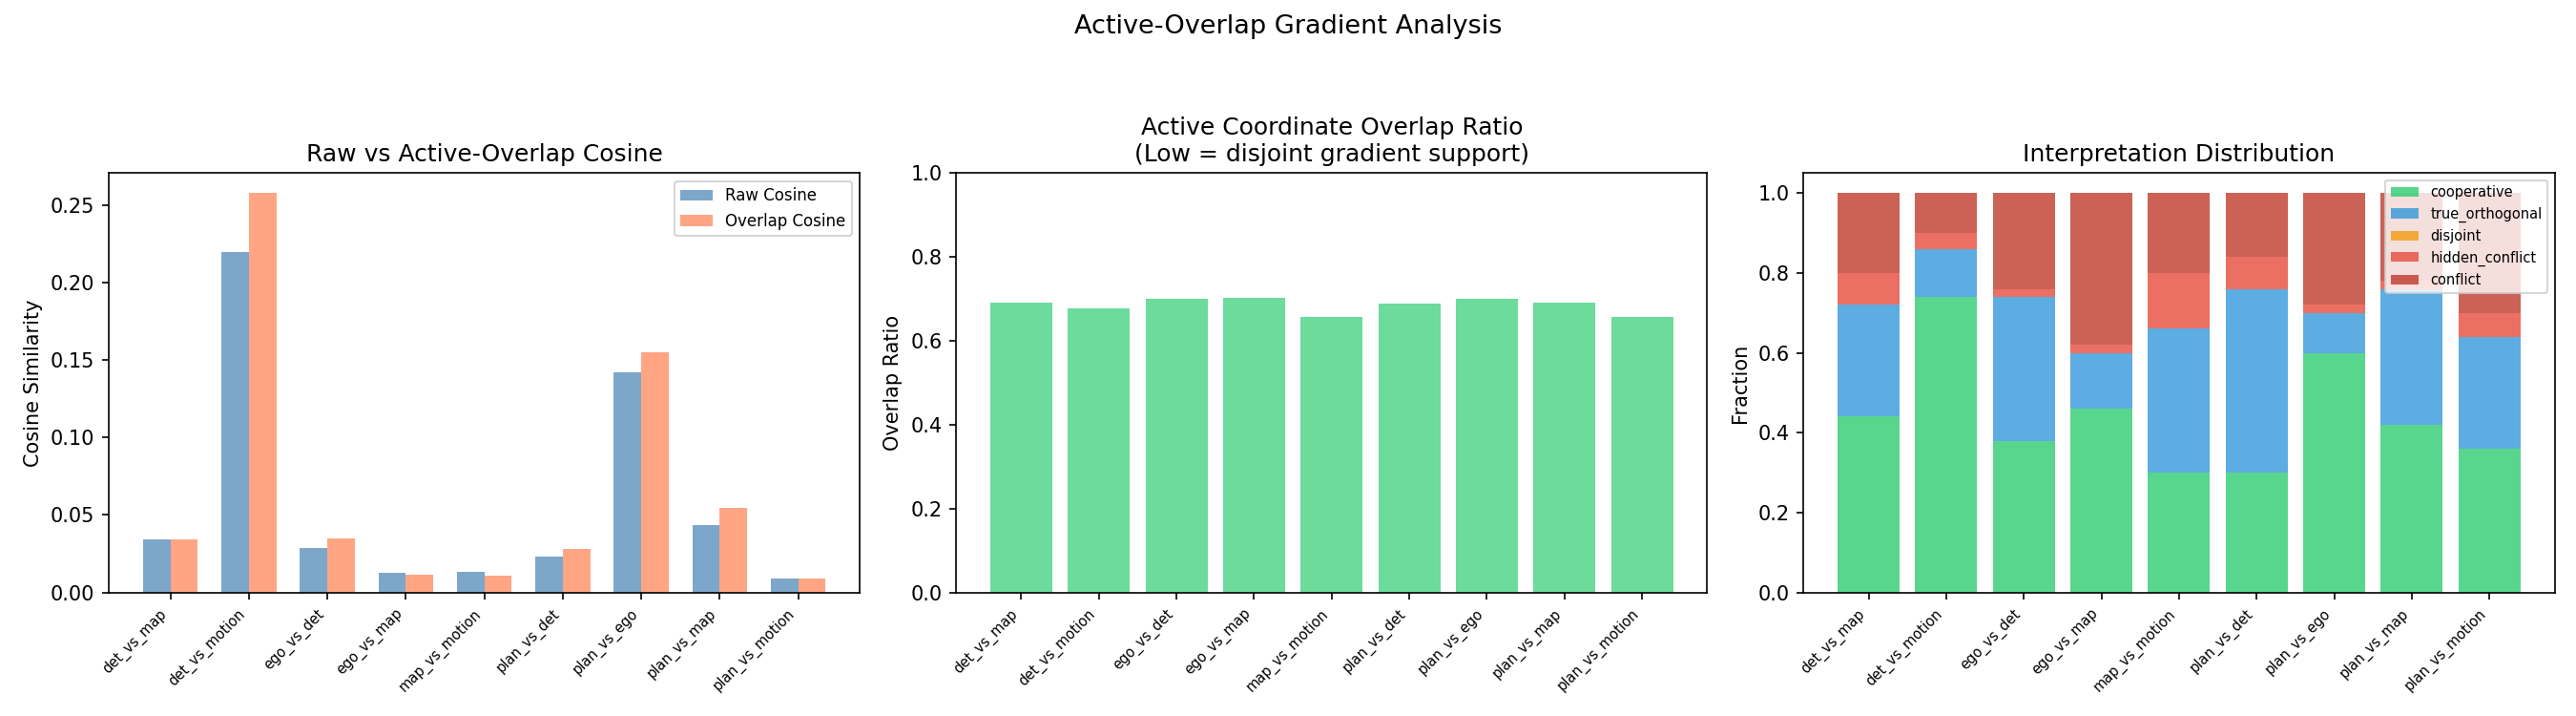


--- active_overlap/per_operation_active_overlap.png ---


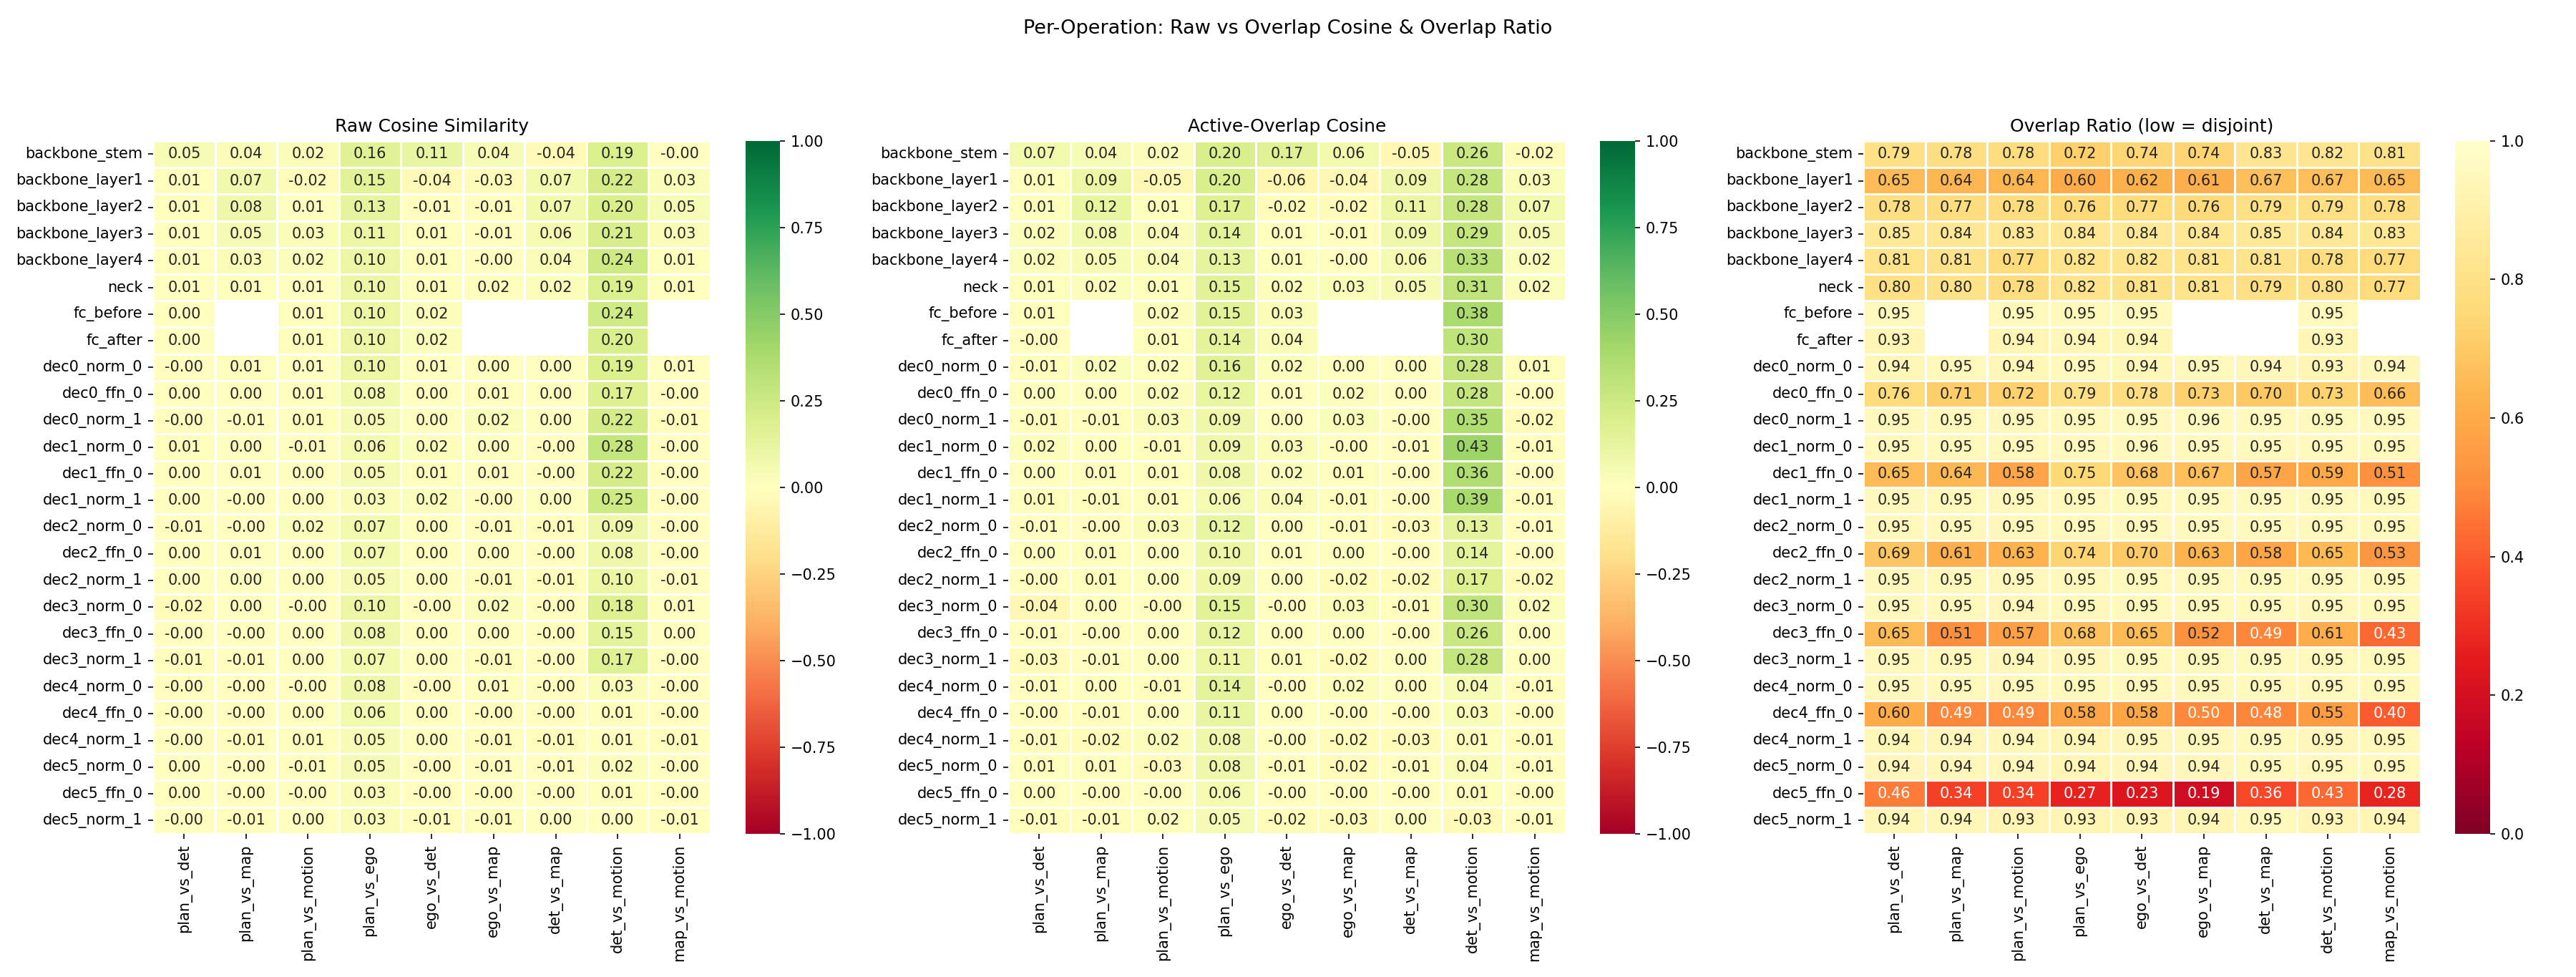


--- advanced/cooperative_vs_conflicting.png ---


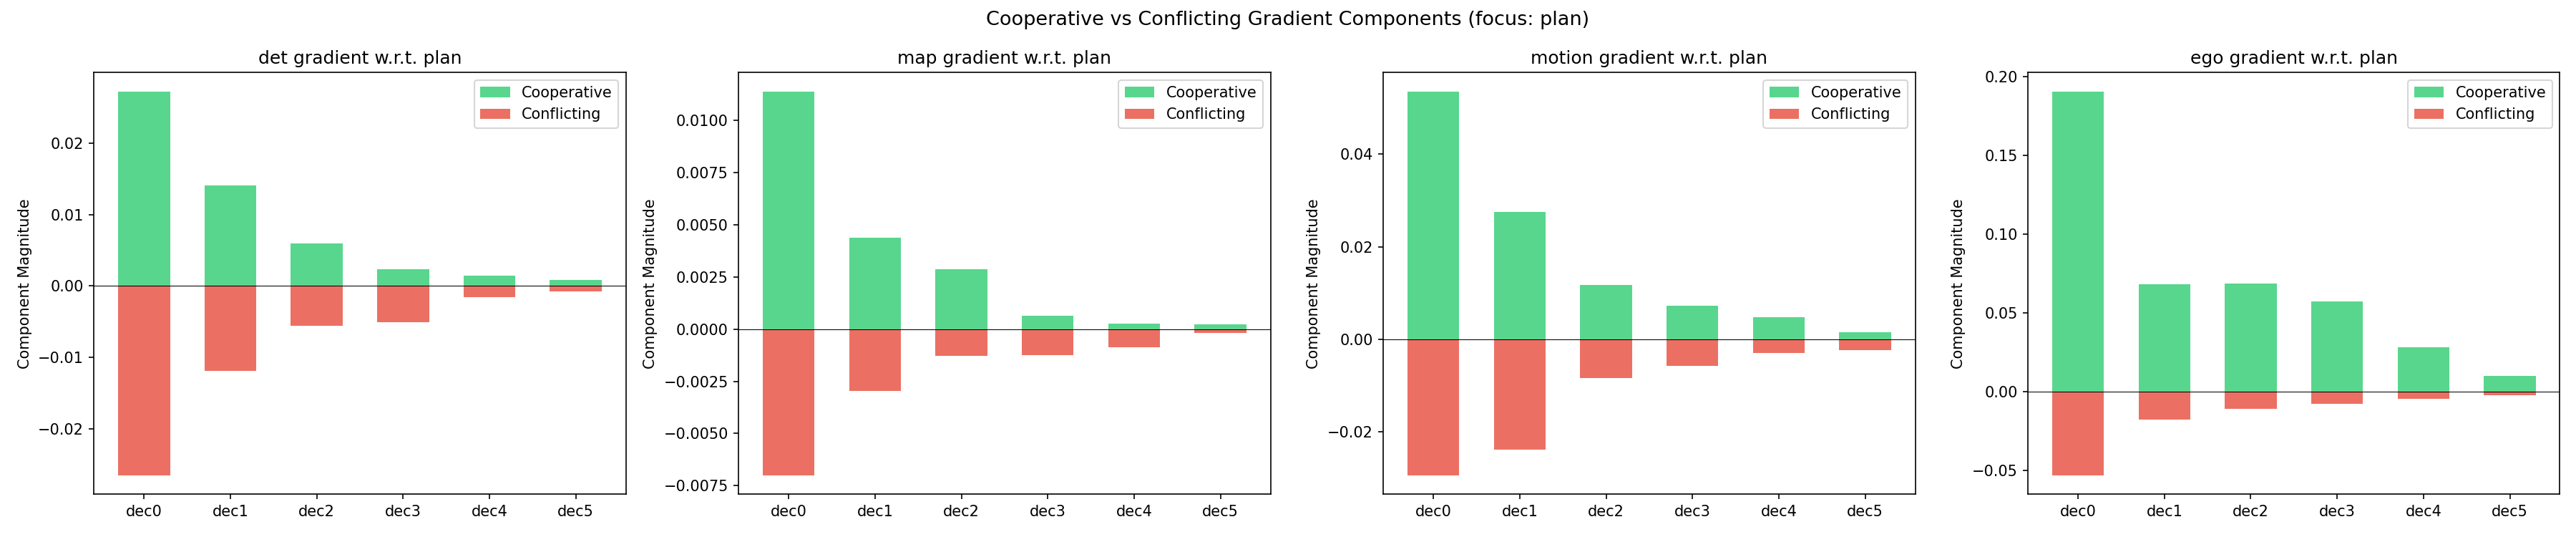


--- advanced/cumulative_gradient_flow.png ---


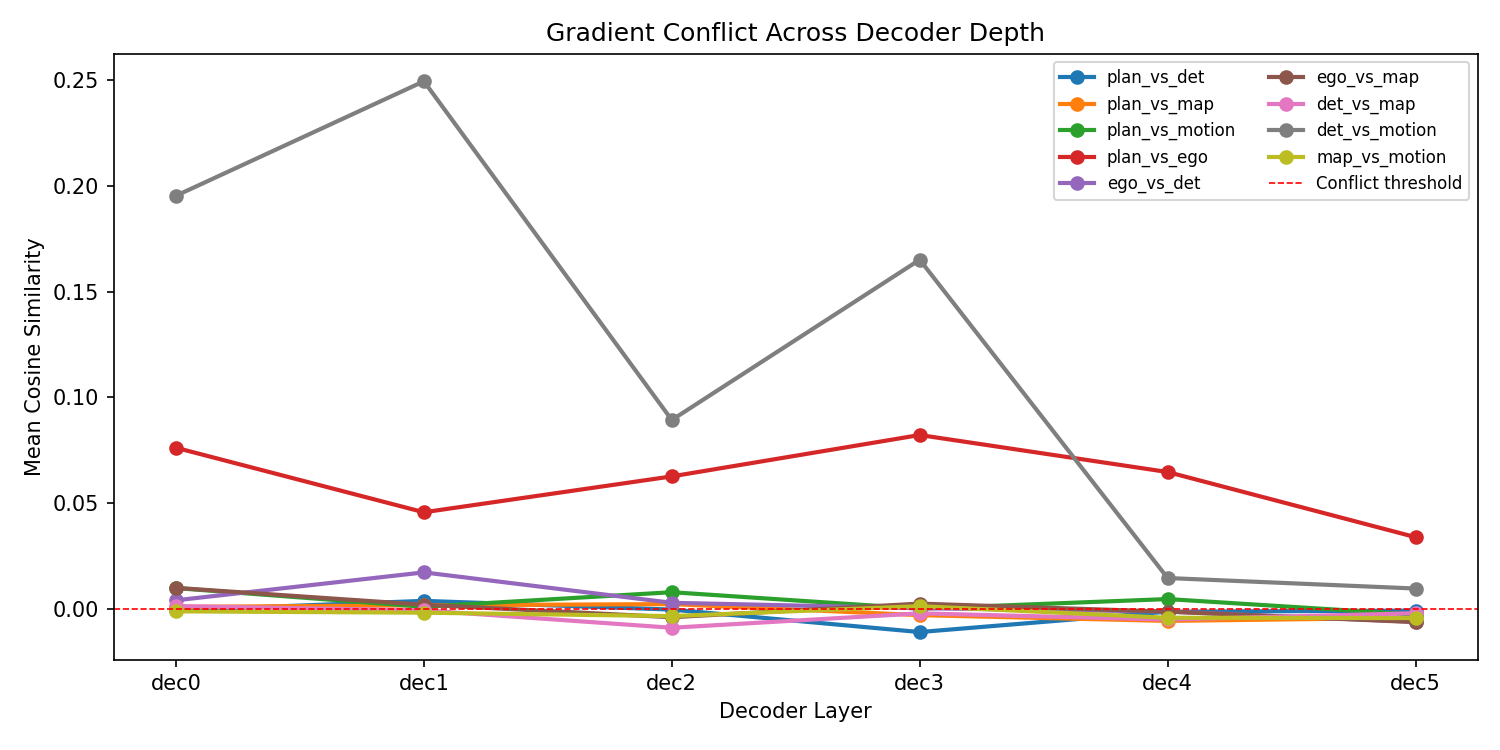

In [27]:
# 개별 plot 표시 — 보고 싶은 파일 인덱스를 변경하세요
# 전체 표시: for f in png_files: display(Image(filename=f))

if png_files:
    # 처음 4개 핵심 plot 표시
    for f in png_files[:4]:
        print(f"\n--- {os.path.relpath(f, args.output_dir)} ---")
        display(Image(filename=f, width=800))

## 12. Random Baseline & Statistical Significance

관측된 cosine similarity가 우연인지 검정합니다.

In [28]:
baseline_results = None
if args.random_baseline:
    try:
        baseline_results = agc.run_random_baseline_analysis(stats, args.output_dir)
        agc.create_baseline_visualizations(stats, baseline_results, args.output_dir)
        print("Random baseline analysis complete")

        # 주요 결과 출력
        if 'statistical_tests' in baseline_results:
            print("\n=== Statistical Tests ===")
            for pair_key, test_res in baseline_results['statistical_tests'].items():
                p_val = test_res.get('welch_t_pvalue', float('nan'))
                sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
                print(f"  {pair_key:20s}  p={p_val:.2e}  {sig}")

        if 'bimodality' in baseline_results:
            print("\n=== Bimodality Detection ===")
            for pair_key, bm in baseline_results['bimodality'].items():
                print(f"  {pair_key:20s}  bimodal={bm.get('is_bimodal', False)}  "
                      f"dip={bm.get('dip_statistic', float('nan')):.4f}")
    except Exception as e:
        print(f"Baseline analysis failed: {e}")
        import traceback; traceback.print_exc()
else:
    print("Random baseline skipped (args.random_baseline=False)")


Generating random baseline for statistical comparison...

RANDOM BASELINE COMPARISON & BIMODALITY ANALYSIS

Random baseline: dim=26000, mean=-0.000126, std=0.006175

  det_vs_map:
    Observed: mean=+0.033972, std=0.191610 (n=50)
    t-test vs random: t=1.246, p=0.2188 [n.s.]
    KS-test vs random: D=0.516, p=0.0000
    Effect size (Cohen's d): 0.2515
    Bimodality: kurtosis=2.450, dip=0.1129
    Distribution: POSSIBLY BIMODAL (mixed signals)
    Neg/Pos split: 48.0% / 52.0%

  det_vs_motion:
    Observed: mean=+0.219883, std=0.237443 (n=50)
    t-test vs random: t=6.486, p=0.0000 [***]
    KS-test vs random: D=0.787, p=0.0000
    Effect size (Cohen's d): 1.3099
    Bimodality: kurtosis=0.091, dip=0.0888
    Distribution: POSSIBLY BIMODAL (mixed signals)
    Neg/Pos split: 18.0% / 82.0%

  ego_vs_det:
    Observed: mean=+0.028853, std=0.196107 (n=50)
    t-test vs random: t=1.034, p=0.3060 [n.s.]
    KS-test vs random: D=0.523, p=0.0000
    Effect size (Cohen's d): 0.2089
    Bimodal

: 

## 13. Recommendations

분석 결과 기반으로 자동 생성된 권장 사항을 확인합니다.

In [ ]:
if args.analysis_mode in ('full', 'direction'):
    try:
        rec = agc.generate_recommendations(
            stats, args.output_dir,
            focus_task=args.focus_task,
            baseline_results=baseline_results,
        )
        print(rec)
    except Exception as e:
        print(f"Recommendations failed: {e}")
else:
    print("Recommendations require 'full' or 'direction' mode")

## 14. Save Results & Raw Data

In [ ]:
# 수치 결과 저장 (JSON + CSV + pickle)
agc.save_results(stats, args.output_dir, analysis_mode=args.analysis_mode)
print(f"Results saved to: {args.output_dir}/")

# 모든 출력 파일 확인
import glob as glob_mod
all_files = sorted(glob_mod.glob(os.path.join(args.output_dir, '**', '*'), recursive=True))
all_files = [f for f in all_files if os.path.isfile(f)]
print(f"\nTotal output files: {len(all_files)}")
for f in all_files:
    size = os.path.getsize(f)
    print(f"  {os.path.relpath(f, args.output_dir):60s}  {size/1024:.1f} KB")

## 15. Custom Analysis (Scratch)

`stats`, `all_results`, `param_groups`, `group_meta` 등을 자유롭게 탐색하세요.

```python
# 예시: 특정 배치의 raw cosine 값 확인
all_results[0]['pairwise_cosine']

# 예시: stats dict 키 구조 확인
list(stats.keys())

# 예시: per-group interference 분석
stats['per_group_interference']
```

In [ ]:
# stats의 최상위 키 확인
print("stats keys:", list(stats.keys()))
print()

# 첫 번째 배치 결과의 키 확인
if all_results:
    print("all_results[0] keys:", list(all_results[0].keys()))

In [ ]:
# 여기서 자유롭게 분석하세요
